# Job Scam Detection — Research Pipeline
This notebook loads the EMSCAD dataset, trains and compares three transformer models (BERT, ALBERT, RoBERTa), and exports the best-performing model for deployment.

In [1]:
# ============================================================
# Cell 1: Setup & Configuration
# ============================================================

import os
import re
import json
import html
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

# ----- Hyperparameters -----
CONFIG = {
    "seed": 42,
    "max_len": 256,
    "batch_size": 16,
    "epochs": 3,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "test_size": 0.15,
    "val_size": 0.15,
}

# ----- Reproducibility -----
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])

# ----- Device -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 2. Data Loading

In [2]:
!gdown "https://drive.google.com/uc?id=1-Bn_Ey676EijYC3zdzqMIrYgA2FAHaOh"

Downloading...
From: https://drive.google.com/uc?id=1-Bn_Ey676EijYC3zdzqMIrYgA2FAHaOh
To: /content/fake_job_postings.csv
100% 50.1M/50.1M [00:00<00:00, 52.5MB/s]


In [3]:
# ============================================================
# Cell 2: Data Loading
# ============================================================

# Load the EMSCAD dataset
# Download from: https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction
df = pd.read_csv("fake_job_postings.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (17880, 18)
Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


## 3. Combine Text Fields

In [4]:
# ============================================================
# Cell 3: Combine Text Fields
# ============================================================

text_columns = ["title", "company_profile", "description", "requirements", "benefits"]

# Capture missing value counts before filling (used in EDA)
missing_counts = df[text_columns].isnull().sum()

for col in text_columns:
    df[col] = df[col].fillna("")

df["text"] = df[text_columns].apply(lambda row: " ".join(row.values), axis=1)

print(f"Combined text column created.")
print(f"Sample text (first 300 chars): {df['text'].iloc[0][:300]}")

Combined text column created.
Sample text (first 300 chars): Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and 


## 4. Exploratory Data Analysis

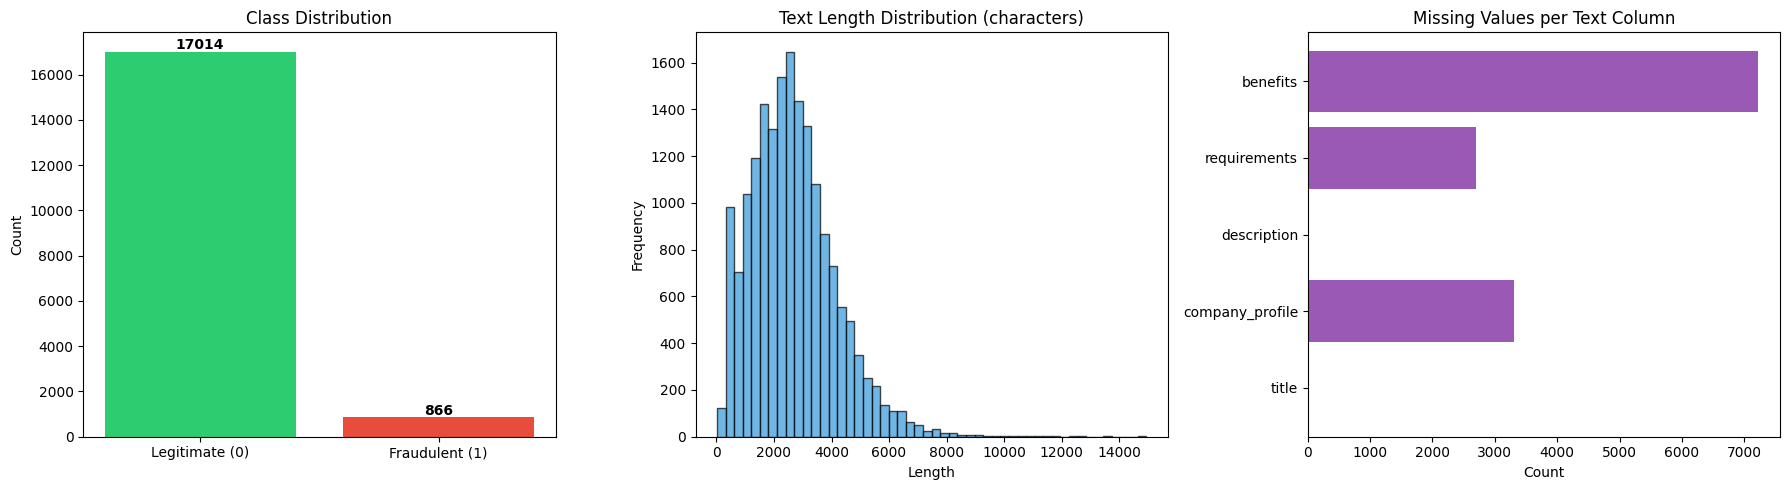


Class distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64

Fraud percentage: 4.84%

Text length stats:
count    17880.000000
mean      2670.464094
std       1465.514148
min         18.000000
25%       1595.000000
50%       2522.000000
75%       3475.000000
max      14945.000000
Name: text_length, dtype: float64


In [5]:
# ============================================================
# Cell 4: Exploratory Data Analysis
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class Distribution
eda_class_counts = df["fraudulent"].value_counts()
axes[0].bar(
    ["Legitimate (0)", "Fraudulent (1)"],
    eda_class_counts.values,
    color=["#2ecc71", "#e74c3c"],
)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(eda_class_counts.values):
    axes[0].text(i, v + 100, str(v), ha="center", fontweight="bold")

# 2. Text Length Distribution
df["text_length"] = df["text"].apply(len)
axes[1].hist(df["text_length"], bins=50, color="#3498db", edgecolor="black", alpha=0.7)
axes[1].set_title("Text Length Distribution (characters)")
axes[1].set_xlabel("Length")
axes[1].set_ylabel("Frequency")

# 3. Missing Values (computed before fillna in Cell 3)
axes[2].barh(text_columns, missing_counts.values, color="#9b59b6")
axes[2].set_title("Missing Values per Text Column")
axes[2].set_xlabel("Count")

plt.tight_layout()
plt.show()

print(f"\nClass distribution:\n{df['fraudulent'].value_counts()}")
print(f"\nFraud percentage: {df['fraudulent'].mean() * 100:.2f}%")
print(f"\nText length stats:\n{df['text_length'].describe()}")

## 5. Text Preprocessing

In [6]:
# ============================================================
# Cell 5: Text Preprocessing
# ============================================================

def clean_text(text):
    """Clean and normalize text for model input."""
    text = html.unescape(text)                          # Decode HTML entities
    text = re.sub(r"<[^>]+>", " ", text)                # Strip HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # Strip URLs
    text = text.lower()                                  # Lowercase
    text = re.sub(r"\s+", " ", text).strip()            # Collapse whitespace
    return text

df["text"] = df["text"].apply(clean_text)

print("Text cleaning complete.")
print(f"Sample cleaned text: {df['text'].iloc[0][:300]}")

Text cleaning complete.
Sample cleaned text: marketing intern we're food52, and we've created a groundbreaking and award-winning cooking site. we support, connect, and celebrate home cooks, and give them everything they need in one place.we have a top editorial, business, and engineering team. we're focused on using technology to find new and 


## 6. Train / Validation / Test Split

In [7]:
# ============================================================
# Cell 6: Stratified Train / Validation / Test Split
# ============================================================

train_val_df, test_df = train_test_split(
    df,
    test_size=CONFIG["test_size"],
    stratify=df["fraudulent"],
    random_state=CONFIG["seed"],
)

val_fraction = CONFIG["val_size"] / (1 - CONFIG["test_size"])
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_fraction,
    stratify=train_val_df["fraudulent"],
    random_state=CONFIG["seed"],
)

print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

print(f"\nFraud ratio - Train: {train_df['fraudulent'].mean():.4f}")
print(f"Fraud ratio - Val:   {val_df['fraudulent'].mean():.4f}")
print(f"Fraud ratio - Test:  {test_df['fraudulent'].mean():.4f}")

Train: 12516 (70.0%)
Val:   2682 (15.0%)
Test:  2682 (15.0%)

Fraud ratio - Train: 0.0484
Fraud ratio - Val:   0.0485
Fraud ratio - Test:  0.0485


## 7. Class Weights

In [8]:
# ============================================================
# Cell 7: Compute Class Weights for Imbalanced Data
# ============================================================

class_counts = train_df["fraudulent"].value_counts().sort_index()
total = len(train_df)
class_weights = torch.tensor(
    [total / (2 * class_counts[0]), total / (2 * class_counts[1])],
    dtype=torch.float32,
).to(device)

print(f"Class weights: {class_weights}")
print(f"  Legitimate (0): {class_weights[0]:.4f}")
print(f"  Fraudulent (1): {class_weights[1]:.4f}")

Class weights: tensor([ 0.5254, 10.3267], device='cuda:0')
  Legitimate (0): 0.5254
  Fraudulent (1): 10.3267


## 8. Custom PyTorch Dataset

In [9]:
# ============================================================
# Cell 8: Custom PyTorch Dataset
# ============================================================

class JobPostingDataset(Dataset):
    """PyTorch Dataset for job posting text classification."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

print("JobPostingDataset class defined.")

JobPostingDataset class defined.


## 9. Training Infrastructure

In [10]:
# ============================================================
# Cell 9: Metrics Function & Custom Weighted-Loss Trainer
# ============================================================

def compute_metrics(pred):
    """Compute accuracy, precision, recall, and F1 for HF Trainer."""
    logits, labels = pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
    }


class WeightedTrainer(Trainer):
    """Custom Trainer that uses weighted cross-entropy loss for class imbalance."""

    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("Metrics function and WeightedTrainer defined.")

Metrics function and WeightedTrainer defined.


## 10. Model Training

In [11]:
# ============================================================
# Cell 10: Train BERT, ALBERT, and RoBERTa
# ============================================================

MODEL_NAMES = {
    "BERT": "bert-base-uncased",
    "ALBERT": "albert-base-v2",
    "RoBERTa": "roberta-base",
}

results = {}
trained_models = {}

for model_label, model_name in MODEL_NAMES.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_label} ({model_name})")
    print(f"{'='*60}")

    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2
    )

    # Create datasets
    train_dataset = JobPostingDataset(
        train_df["text"], train_df["fraudulent"], tokenizer, CONFIG["max_len"]
    )
    val_dataset = JobPostingDataset(
        val_df["text"], val_df["fraudulent"], tokenizer, CONFIG["max_len"]
    )
    test_dataset = JobPostingDataset(
        test_df["text"], test_df["fraudulent"], tokenizer, CONFIG["max_len"]
    )

    # Training arguments
    output_dir = f"./training_output/{model_label.lower()}"
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=CONFIG["epochs"],
        per_device_train_batch_size=CONFIG["batch_size"],
        per_device_eval_batch_size=CONFIG["batch_size"],
        learning_rate=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
        warmup_ratio=CONFIG["warmup_ratio"],
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        seed=CONFIG["seed"],
    )

    # Create trainer with weighted loss
    trainer = WeightedTrainer(
        class_weights=class_weights,
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )

    # Train
    trainer.train()

    # Evaluate on test set
    test_results = trainer.predict(test_dataset)
    test_preds = np.argmax(test_results.predictions, axis=-1)
    test_labels = test_df["fraudulent"].values

    metrics = {
        "accuracy": accuracy_score(test_labels, test_preds),
        "precision": precision_score(test_labels, test_preds, zero_division=0),
        "recall": recall_score(test_labels, test_preds, zero_division=0),
        "f1": f1_score(test_labels, test_preds, zero_division=0),
    }

    results[model_label] = metrics
    trained_models[model_label] = {
        "model": trainer.model,
        "tokenizer": tokenizer,
        "predictions": test_preds,
    }

    print(f"\n{model_label} Test Results:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")


Training: BERT (bert-base-uncased)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


RoBERTa Test Results:
  accuracy: 0.9847
  precision: 0.8678
  recall: 0.8077
  f1: 0.8367


## 11. Comparative Evaluation

COMPARATIVE EVALUATION MATRIX
         accuracy  precision  recall      f1
Model                                       
BERT       0.9870     0.9130  0.8077  0.8571
ALBERT     0.9892     0.9469  0.8231  0.8807
RoBERTa    0.9847     0.8678  0.8077  0.8367



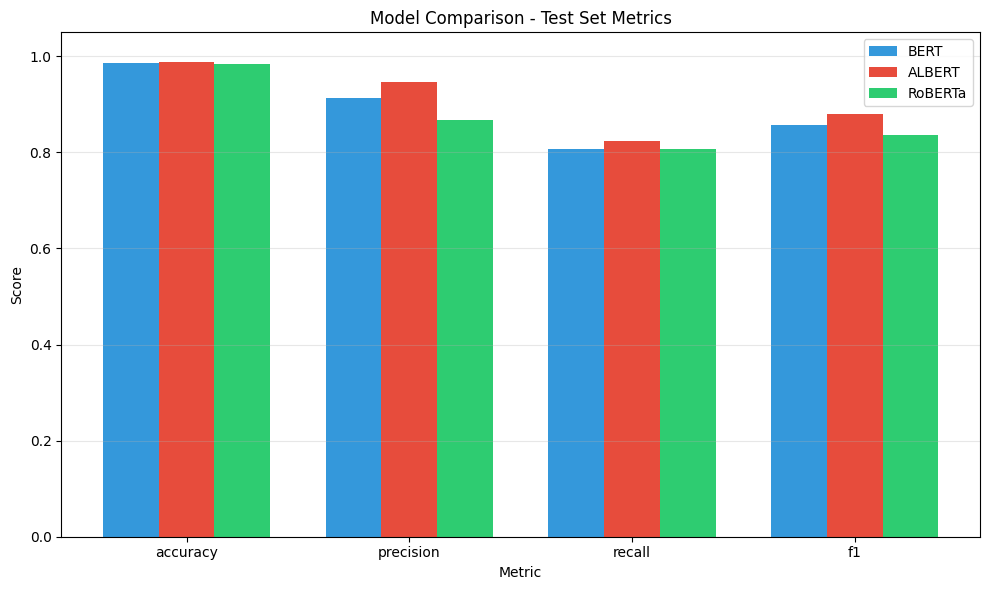

In [12]:
# ============================================================
# Cell 11: Comparative Evaluation Matrix
# ============================================================

comparison_df = pd.DataFrame(results).T
comparison_df.index.name = "Model"
print("=" * 60)
print("COMPARATIVE EVALUATION MATRIX")
print("=" * 60)
print(comparison_df.round(4).to_string())
print()

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df.columns))
width = 0.25
models = list(comparison_df.index)
colors = ["#3498db", "#e74c3c", "#2ecc71"]

for i, model_name in enumerate(models):
    values = comparison_df.loc[model_name].values
    ax.bar(x + i * width, values, width, label=model_name, color=colors[i])

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Model Comparison - Test Set Metrics")
ax.set_xticks(x + width)
ax.set_xticklabels(comparison_df.columns)
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Confusion Matrices

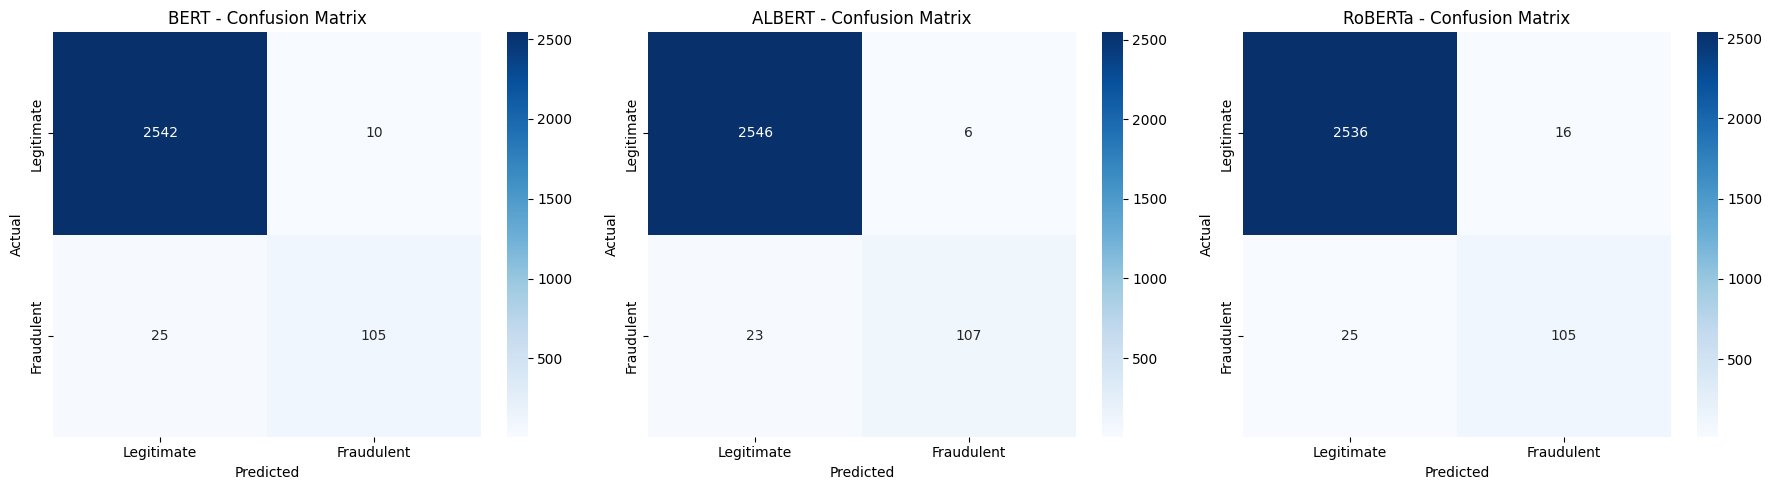

In [13]:
# ============================================================
# Cell 12: Confusion Matrices
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
test_labels = test_df["fraudulent"].values

for idx, (model_label, model_data) in enumerate(trained_models.items()):
    cm = confusion_matrix(test_labels, model_data["predictions"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Legitimate", "Fraudulent"],
        yticklabels=["Legitimate", "Fraudulent"],
        ax=axes[idx],
    )
    axes[idx].set_title(f"{model_label} - Confusion Matrix")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 13. Export Best Model

In [14]:
# ============================================================
# Cell 13: Export Best Model
# ============================================================

best_model_name = max(results, key=lambda k: results[k]["f1"])
best_metrics = results[best_model_name]

print(f"Best model: {best_model_name} (F1: {best_metrics['f1']:.4f})")

# Save model and tokenizer
save_dir = "./best_model"
os.makedirs(save_dir, exist_ok=True)

best_model_obj = trained_models[best_model_name]["model"]
best_tokenizer = trained_models[best_model_name]["tokenizer"]

best_model_obj.save_pretrained(save_dir)
best_tokenizer.save_pretrained(save_dir)

# Save metadata
meta = {
    "model_name": best_model_name,
    "hf_model_id": MODEL_NAMES[best_model_name],
    "metrics": best_metrics,
    "config": CONFIG,
    "exported_at": datetime.now().isoformat(),
}

with open(os.path.join(save_dir, "model_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print(f"\nModel saved to: {save_dir}/")
print(f"Metadata saved to: {save_dir}/model_meta.json")

print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Best Model: {best_model_name} ({MODEL_NAMES[best_model_name]})")
for metric, value in best_metrics.items():
    print(f"  {metric}: {value:.4f}")

Best model: ALBERT (F1: 0.8807)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to: ./best_model/
Metadata saved to: ./best_model/model_meta.json

FINAL SUMMARY
Best Model: ALBERT (albert-base-v2)
  accuracy: 0.9892
  precision: 0.9469
  recall: 0.8231
  f1: 0.8807


In [15]:
import shutil
from google.colab import drive

# Zip kedua folder sekaligus
shutil.make_archive('hasil_training', 'zip', '/content', 'training_output')
shutil.make_archive('best_model', 'zip', '/content', 'best_model')

# Mount Google Drive dan copy kesana
drive.mount('/content/drive')

shutil.copy('hasil_training.zip', '/content/drive/MyDrive/hasil_training.zip')
shutil.copy('best_model.zip', '/content/drive/MyDrive/best_model.zip')

print("Selesai! Cek Google Drive kamu.")

Mounted at /content/drive
Selesai! Cek Google Drive kamu.
